# Day 08. Exercise 04
# Regression

## 0. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [22]:
df = pd.read_csv('../../datasets/checker_regression.csv')
df.head()

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN


In [23]:
df.drop(columns='uid', inplace=True)
df.fillna(0, inplace=True)
df.head()

,num_commits,pageviews,AVG(diff)
0,62,28.0,0.0
1,62,28.0,0.0
2,62,28.0,0.0
3,62,28.0,0.0
4,62,28.0,0.0


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='AVG(diff)')
y = df['AVG(diff)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [25]:
from sklearn.base import BaseEstimator
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error


def crossval(n_splits, X, y, model):
    """"""
    test_rmses = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_rmse = np.sqrt(root_mean_squared_error(y_train, train_pred))
        test_rmse = np.sqrt(root_mean_squared_error(y_test, test_pred))
        test_rmses.append(test_rmse)
        
        print(f"train - {train_rmse} | test - {test_rmse}")

    avg_rmse = np.mean(test_rmses)
    print(f"Average RMSE on crossval is {avg_rmse}")
    return avg_rmse

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
crossval(10, X_train, y_train, model)

train - 6.622079360952892 | test - 6.481920175057605
train - 6.465370536688491 | test - 7.628282665055665
train - 6.68547230924325 | test - 5.907006026189044
train - 6.232615536757512 | test - 8.752228147399139
train - 6.697820360581634 | test - 5.648390467086282
train - 6.697390050877123 | test - 5.510809073119931
train - 6.4862802004644475 | test - 7.4902144245186575
train - 6.7583663516899115 | test - 4.067431642867009
train - 6.603537674522719 | test - 6.771667532163109
train - 6.653346406947379 | test - 6.2505094246201285
Average RMSE on crossval is 6.4508459578076565


np.float64(6.4508459578076565)

In [27]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
crossval(10, X_train, y_train, model)

train - 0.0 | test - 6.081950599259777
train - 0.0 | test - 7.379723704033866
train - 0.0 | test - 5.785875890307082
train - 0.0 | test - 7.7694707486511945
train - 0.0 | test - 4.380373232020482
train - 0.0 | test - 4.840811075907191
train - 0.0 | test - 4.8080425834204625
train - 0.0 | test - 8.558983988587737
train - 0.0 | test - 7.751834668425089
train - 0.0 | test - 6.80706845621876
Average RMSE on crossval is 6.416413494683164


np.float64(6.416413494683164)

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
crossval(10, X_train, y_train, model)

train - 3.8106922396864245 | test - 4.89032964790574
train - 3.709061633911406 | test - 6.033888014651776
train - 3.604761023088756 | test - 6.270947994080208
train - 3.4343677901113296 | test - 7.572934451116791
train - 3.8792023343444746 | test - 4.886626947399277
train - 3.8407276779277577 | test - 3.3101117481130573
train - 3.829299740325689 | test - 5.137872730827762
train - 3.5348301266415687 | test - 7.504398219847377
train - 3.6054704346305595 | test - 6.318468127945047
train - 3.817102192434744 | test - 6.032674180712695
Average RMSE on crossval is 5.795825206259972


np.float64(5.795825206259972)

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

### Logreg


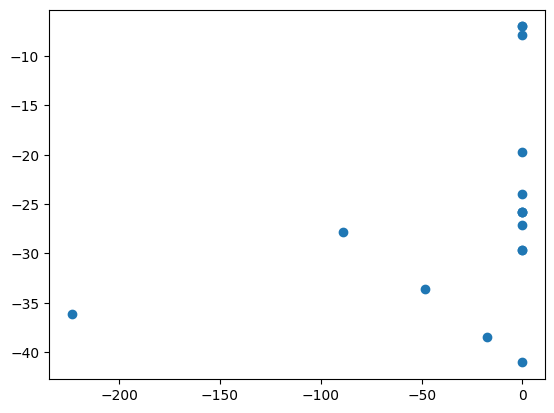

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)
predict = model.predict(X_test)

plt.scatter(y_test, predict)
plt.xlabel('actual average difference')
plt.ylabel('prediction made by a model')

### decision tree

Text(0, 0.5, 'prediction made by a model')

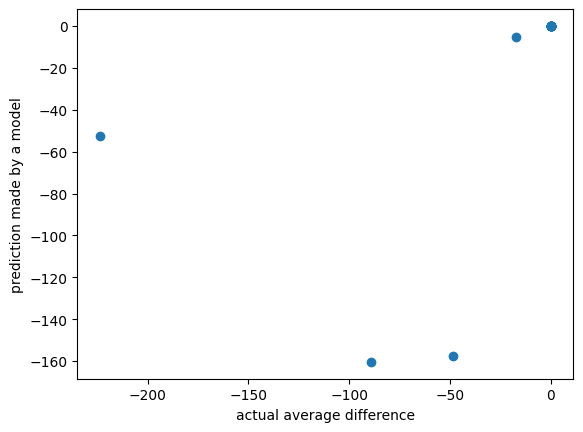

In [37]:
model = DecisionTreeRegressor()

model.fit(X_train, y_train)
predict = model.predict(X_test)

plt.scatter(y_test, predict)
plt.xlabel('actual average difference')
plt.ylabel('prediction made by a model')

### random forest

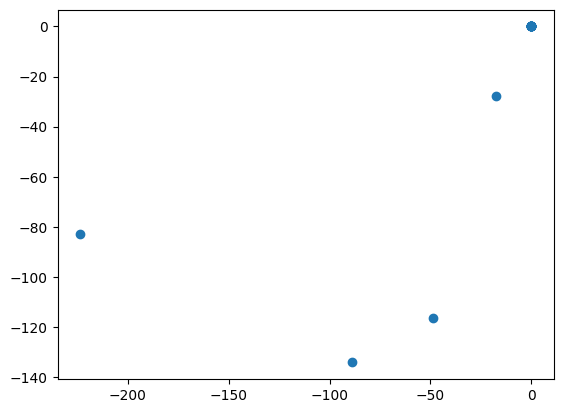

In [ ]:
model = RandomForestRegressor()

model.fit(X_train, y_train)
predict = model.predict(X_test)

plt.scatter(y_test, predict)
plt.xlabel('actual average difference')
plt.ylabel('prediction made by a model')

## How would plot look like in the ideal case?
- line